In [1]:
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
# Set up the credentials
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name("sheets_keys.json", scope)
client = gspread.authorize(creds)

# Open the Google Sheet
sheet1 = client.open("AU MIH Database 2025-26").worksheet('Form Responses')
sheet2 = client.open("AU MIH Database 2025-26").worksheet('TOI')
sheet3 = client.open("AU MIH Database 2025-26").worksheet('Jump Testing')
sheet4 = client.open("AU MIH Database 2025-26").worksheet('EWMA sRPE')

# Get all values and convert to a Pandas DataFrame
data1 = sheet1.get_all_records()
data2 = sheet2.get_all_records()
data3 = sheet3.get_all_records()
data4 = sheet4.get_all_records()

form_responses_mih = pd.DataFrame(data1)
game_data_mih = pd.DataFrame(data2)
jump_testing_mih = pd.DataFrame(data3)
ewma_acwr_mih = pd.DataFrame(data4)


In [3]:
form_responses_mih["Date"] = pd.to_datetime(form_responses_mih.pop("Timestamp")).dt.date
form_responses_mih["sRPE"] = pd.to_numeric(form_responses_mih["sRPE"], errors="coerce").astype("Int64")
form_responses_mih.drop(columns=['Datapoint', 'What\'s on your mind?','Sore Areas', 'Did you participate in yesterday\'s training?','Session Minutes', 'Session Intensity'], inplace=True)

game_data_mih["Date"] = pd.to_datetime(game_data_mih["Date"]).dt.date
game_data_mih["Game %"] = pd.to_numeric(game_data_mih["Game %"], errors="coerce").astype("float")
game_data_mih.drop(columns=['Shifts', 'TOI','Game Flag','TOI - Decimal','Secs / Shift'], inplace=True)

jump_testing_mih["Date"] = pd.to_datetime(jump_testing_mih["Date"]).dt.date
jump_testing_mih["CMJ"] = pd.to_numeric(jump_testing_mih["CMJ"], errors="coerce").astype("float")

ewma_acwr_mih["Date"] = pd.to_datetime(ewma_acwr_mih["Date"]).dt.date
ewma_acwr_mih.drop(columns=['sRPE'], inplace=True)


In [4]:
from functools import reduce

mih_dfs = [form_responses_mih, game_data_mih, jump_testing_mih, ewma_acwr_mih]  # my 4 date/name dataframes

mih_merged = reduce(lambda left, right: pd.merge(left, right, on=["Date", "Name"], how="outer"), mih_dfs)

mih_merged = mih_merged.replace(["NaN", "nan", None], 0).fillna(0)

mih_merged = mih_merged.sort_values(by=["Name", "Date"]).reset_index(drop=True)
mih_merged["CMJ"] = mih_merged["CMJ"].replace(0, np.nan)

mih_merged = mih_merged.iloc[2:].reset_index(drop=True)

In [5]:
mih_merged.drop(columns=['Wellness Score', 'Wellness %', 'Acute', 'Chronic'], inplace=True)

In [6]:
# Check the actual dtype
print(mih_merged["Date"].dtype)
print(mih_merged["Date"].head())

object
0    2025-10-30
1    2025-10-31
2    2025-11-02
3    2025-11-02
4    2025-11-02
Name: Date, dtype: object


In [7]:
mih_merged["Date"] = pd.to_datetime(mih_merged["Date"])


In [8]:
def weighted_game_minutes(df, toi_col="Game %", date_col="Date",
                           athlete_col="Name", lookback_days=4, tau=2.0):
    """
    For each row, look back `lookback_days` for that athlete's game data
    and compute an exponential decay-weighted sum of TOI values.
    
    Weight formula: TOI * exp(-days_elapsed / tau)
    
    tau: decay constant in days. Smaller = more weight on recent games.
         Suggested starting point: 2.0 days.
    """
    df = df.sort_values([athlete_col, date_col]).copy()
    weighted = []

    for _, row in df.iterrows():
        athlete = row[athlete_col]
        current_date = row[date_col]
        window_start = current_date - pd.Timedelta(days=lookback_days)

        # Get this athlete's actual game days in the lookback window
        mask = (
            (df[athlete_col] == athlete) &
            (df[date_col] < current_date) &   # exclude current row
            (df[date_col] >= window_start) &
            (df[toi_col] > 0.0)               # only rows with real game data
        )

        games = df.loc[mask, [date_col, toi_col]].copy()

        if games.empty:
            weighted.append(0.0)
        else:
            games["days_elapsed"] = (current_date - games[date_col]).dt.days
            games["decay_weight"] = np.exp(-games["days_elapsed"] / tau)
            games["contribution"] = games[toi_col] * games["decay_weight"]
            weighted.append(games["contribution"].sum())

    df["weighted_game_toi"] = weighted
    return df

# Apply it
mih_processed = weighted_game_minutes(mih_merged, tau=2.0)

In [9]:
# Remove post-practice testing dates (protocol changed Jan 13, 2026 onward)
mih_processed = mih_processed[mih_processed["Date"] < "2026-01-13"].copy()


In [10]:
# CALCULATE CMJ DEVIATION FROM INDIVIDUAL BASELINE

# Baseline = each athlete's mean CMJ across all their jump days.
# Deviation = (observed - baseline) / baseline * 100  (percent deviation)

# Drop rows with no CMJ measurement (non-jump days)
mih_processed = mih_processed.dropna(subset=["CMJ"]).copy()

In [11]:
athlete_baseline = mih_processed.groupby("Name")["CMJ"].mean().rename("cmj_baseline")
mih_processed = mih_processed.join(athlete_baseline, on="Name")

# Percent deviation from baseline
mih_processed["cmj_deviation"] = (mih_processed["CMJ"] - mih_processed["cmj_baseline"]) / mih_processed["cmj_baseline"] * 100

print(f"Dataset shape after filtering to jump days: {mih_processed.shape}")
print(f"CMJ deviation — mean: {mih_processed['cmj_deviation'].mean():.2f}%, "
      f"std: {mih_processed['cmj_deviation'].std():.2f}%\n")

Dataset shape after filtering to jump days: (220, 15)
CMJ deviation — mean: 0.00%, std: 3.89%



In [12]:
# DEFINE FEATURES AND TARGET

FEATURES = [
    "Sleep Quality",
    "Sleep Hours",
    "Soreness",
    "Motivation",
    "Stress",
    "Fatigue",
    "sRPE",
    "ACWR",
    "weighted_game_toi",
]

TARGET = "cmj_deviation"
GROUP  = "Name"   # used for GroupKFold

X = mih_processed[FEATURES]
y = mih_processed[TARGET]
groups = mih_processed[GROUP]

In [13]:
# Quality check: missing values and target distribution

print("Missing values per feature:")
print(X.isnull().sum())
print(f"\nClass distribution of target (mean ± std): "
      f"{y.mean():.2f} ± {y.std():.2f}\n")

Missing values per feature:
Sleep Quality        0
Sleep Hours          0
Soreness             0
Motivation           0
Stress               0
Fatigue              0
sRPE                 0
ACWR                 0
weighted_game_toi    0
dtype: int64

Class distribution of target (mean ± std): 0.00 ± 3.89



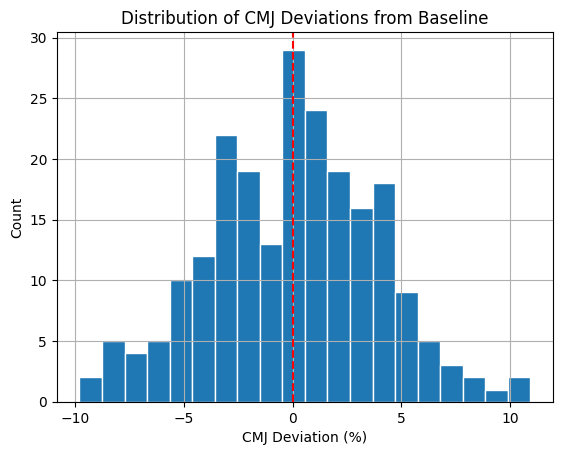

In [14]:
mih_processed["cmj_deviation"].hist(bins=20, edgecolor="white")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("CMJ Deviation (%)")
plt.ylabel("Count")
plt.title("Distribution of CMJ Deviations from Baseline")
plt.show()

In [16]:
# Build Pipeline

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # handle any remaining NaNs in features
    ("scaler",  StandardScaler()),                  # good practice for permutation importance
    ("model",   RandomForestRegressor(
        n_estimators=500,
        max_features="sqrt",      # standard for regression RFs
        min_samples_leaf=5,       # regularize to prevent overfitting (small N)
        random_state=42,
        n_jobs=-1,
    ))
])

In [17]:
# Grouped Cross-Validation

gkf = GroupKFold(n_splits=5)        # prevent data leakage due to repeated measures from same athletes

cv_r2  = cross_val_score(pipeline, X, y, groups=groups, cv=gkf, scoring="r2")
cv_mae = cross_val_score(pipeline, X, y, groups=groups, cv=gkf,
                         scoring="neg_mean_absolute_error")

print("=== Grouped 5-Fold Cross-Validation ===")
print(f"R²  per fold: {cv_r2.round(3)}")
print(f"R²  mean ± std: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"MAE per fold: {(-cv_mae).round(3)}")
print(f"MAE mean ± std: {(-cv_mae).mean():.3f} ± {(-cv_mae).std():.3f} %\n")

=== Grouped 5-Fold Cross-Validation ===
R²  per fold: [0.277 0.135 0.065 0.247 0.249]
R²  mean ± std: 0.195 ± 0.081
MAE per fold: [2.216 2.825 3.781 2.834 2.298]
MAE mean ± std: 2.791 ± 0.558 %



In [18]:
# Fit on full dataset for feature importance

pipeline.fit(X, y)
rf_model = pipeline.named_steps["model"]

In [19]:
# PERMUTATION IMPORTANCES

# Transform X through the pipeline before passing to permutation_importance
X_transformed = pipeline[:-1].transform(X)  # imputer + scaler only

perm_result = permutation_importance(
    rf_model,
    X_transformed,
    y,
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": perm_result.importances_mean,
    "std":        perm_result.importances_std,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n=== Permutation Feature Importances ===")
print(perm_df.to_string(index=False))


=== Permutation Feature Importances ===
          feature  importance      std
weighted_game_toi    0.212411 0.031904
             ACWR    0.069707 0.006264
           Stress    0.058508 0.010013
      Sleep Hours    0.054675 0.010289
             sRPE    0.052019 0.004464
       Motivation    0.050158 0.008545
         Soreness    0.037412 0.003516
    Sleep Quality    0.030246 0.005561
          Fatigue    0.020876 0.002683


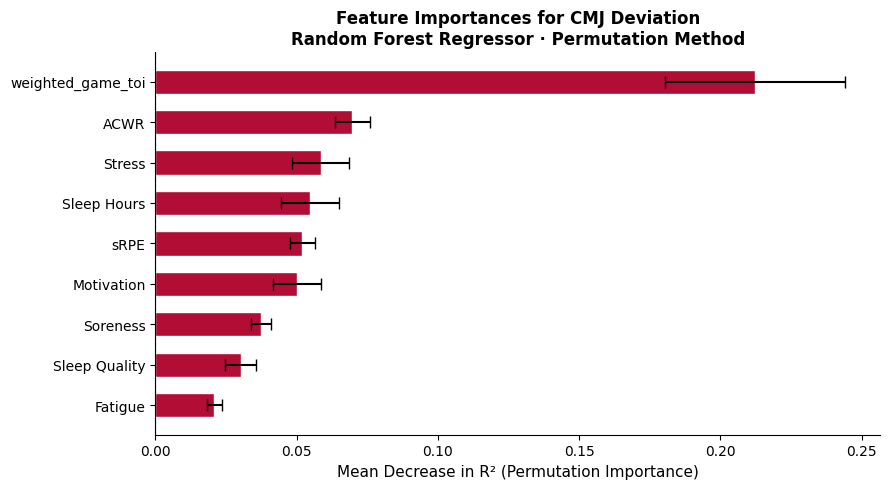

In [20]:
# PLOT: PERMUTATION IMPORTANCES

fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#B20D35" if v >= 0 else "#BDBDBD" for v in perm_df["importance"]]

ax.barh(
    perm_df["feature"][::-1],
    perm_df["importance"][::-1],
    xerr=perm_df["std"][::-1],
    color=colors[::-1],
    edgecolor="white",
    height=0.6,
    capsize=4,
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean Decrease in R² (Permutation Importance)", fontsize=11)
ax.set_title("Feature Importances for CMJ Deviation\n"
             "Random Forest Regressor · Permutation Method", fontsize=12, fontweight="bold")
ax.tick_params(axis="y", labelsize=10)
sns.despine()
plt.tight_layout()
plt.savefig("cmj_permutation_importances.png", dpi=150, bbox_inches="tight")
plt.show()


=== MDI (Mean Decrease Impurity) Importances — for comparison ===
          feature  importance
weighted_game_toi    0.306337
             ACWR    0.136688
      Sleep Hours    0.111425
             sRPE    0.106749
       Motivation    0.088481
           Stress    0.081758
    Sleep Quality    0.068489
         Soreness    0.058928
          Fatigue    0.041145


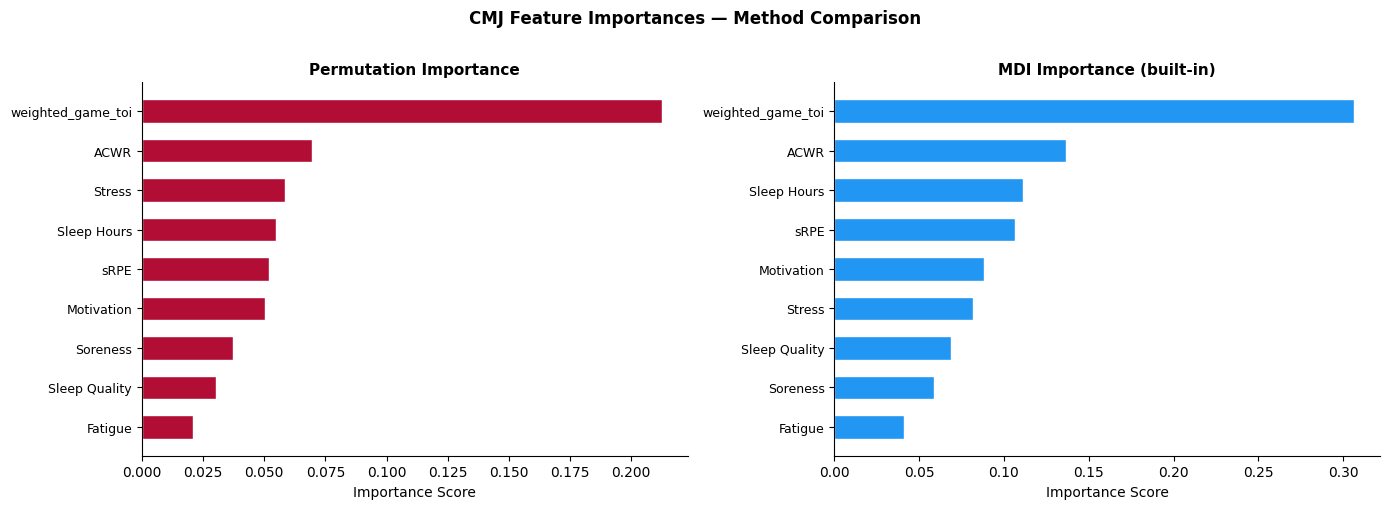

In [21]:
# Mean Decrease Impurity Importance for comparison

# MDI is biased toward high-cardinality features, but if similar to Permutation Importances,
# could prove robustness.

mdi_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n=== MDI (Mean Decrease Impurity) Importances — for comparison ===")
print(mdi_df.to_string(index=False))

fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in zip(
    axes,
    [perm_df, mdi_df],
    ["Permutation Importance", "MDI Importance (built-in)"],
    ["#B20D35", "#2196F3"],
):
    ax.barh(data["feature"][::-1], data["importance"][::-1],
            color=color, edgecolor="white", height=0.6)
    ax.set_xlabel("Importance Score", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelsize=9)
    sns.despine(ax=ax)

plt.suptitle("CMJ Feature Importances — Method Comparison", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("perm_vs_mdi_comparison.png", dpi=150, bbox_inches="tight")
plt.show()